In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd

In [2]:
# File path
file_path = "Results_Histogram_C43C25_12dB_2026-07-28T14_55_22.csv"

In [3]:
# Load ID1000 histogram file
df = pd.read_csv(file_path, sep=";")

# Display columns to confirm structure
print(df.columns)
display(df.head())

# Convert bin centre from ps to ns
df["BinCenter_ns"] = df["BinCenter (ps)"] / 1000

hist_col = "Histo01"

# Convert time to ns
df["BinCenter_ns"] = df["BinCenter (ps)"] / 1000

# Find peaks
peaks, properties = find_peaks(
    df[hist_col].to_numpy(),
    prominence=10,
    distance=50
)

# Extract peak times and counts together
peak_times_ns = df["BinCenter_ns"].iloc[peaks].to_numpy()
peak_counts = df[hist_col].iloc[peaks].to_numpy()

# Sort by time
order = np.argsort(peak_times_ns)
peak_times_ns = peak_times_ns[order]
peak_counts = peak_counts[order]

print("Number of detected peaks:", len(peak_times_ns))
print("Number of peak counts:", len(peak_counts))

# Calculate separations
peak_separations_ns = np.diff(peak_times_ns)

print("\nDetected peaks:")
for i, (t, c) in enumerate(zip(peak_times_ns, peak_counts)):
    print(f"Peak {i+1}: time = {t:.3f} ns, counts = {c}")

print("\nPeak-to-peak separations:")
for i, sep in enumerate(peak_separations_ns):
    print(f"Peak {i+1} to Peak {i+2}: {sep:.3f} ns")

Index(['BinCenter (ps)', 'Histo01', 'Histo02', 'Histo03', 'Histo04'], dtype='str')


,BinCenter (ps),Histo01,Histo02,Histo03,Histo04
0,50,88524,1122787,1122787,0
1,150,131573,764876,764876,0
2,250,222460,630405,630405,0
3,350,295584,579206,579206,0
4,450,263710,559854,559854,0


Number of detected peaks: 9
Number of peak counts: 9

Detected peaks:
Peak 1: time = 0.350 ns, counts = 295584
Peak 2: time = 7.050 ns, counts = 1025
Peak 3: time = 12.550 ns, counts = 25204
Peak 4: time = 19.350 ns, counts = 964
Peak 5: time = 25.050 ns, counts = 25072
Peak 6: time = 30.650 ns, counts = 948
Peak 7: time = 37.550 ns, counts = 25203
Peak 8: time = 42.750 ns, counts = 966
Peak 9: time = 48.350 ns, counts = 1018

Peak-to-peak separations:
Peak 1 to Peak 2: 6.700 ns
Peak 2 to Peak 3: 5.500 ns
Peak 3 to Peak 4: 6.800 ns
Peak 4 to Peak 5: 5.700 ns
Peak 5 to Peak 6: 5.600 ns
Peak 6 to Peak 7: 6.900 ns
Peak 7 to Peak 8: 5.200 ns
Peak 8 to Peak 9: 5.600 ns


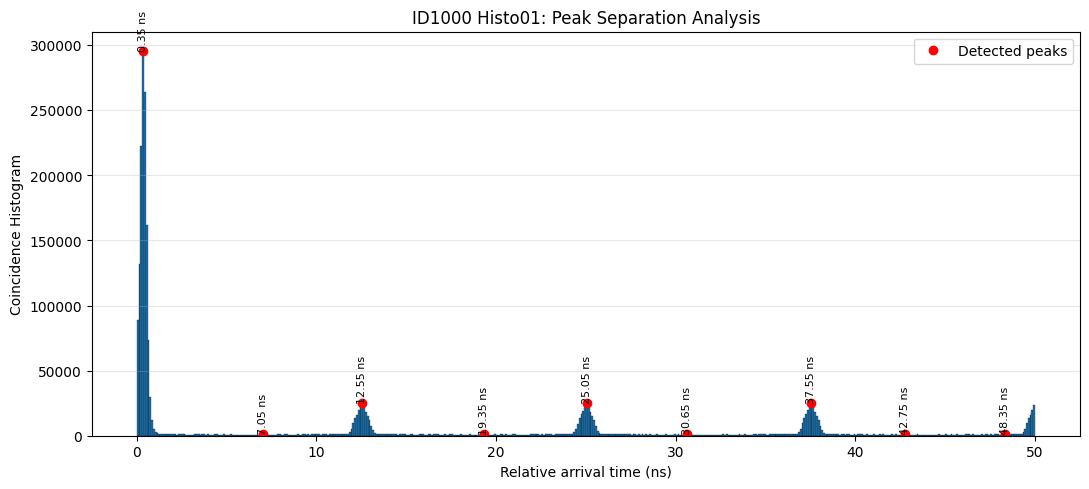

In [4]:
# Histogram Plot
plt.figure(figsize=(11, 5))

plt.bar(
    df["BinCenter_ns"],
    df[hist_col],
    width=0.1,
    edgecolor="black",
    linewidth=0.2
)

plt.plot(
    peak_times_ns,
    peak_counts,
    "ro",
    label="Detected peaks"
)

for t, c in zip(peak_times_ns, peak_counts):
    plt.text(
        t,
        c,
        f"{t:.2f} ns",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.xlabel("Relative arrival time (ns)")
plt.ylabel("Coincidence Histogram")
plt.title("ID1000 Histo01: Peak Separation Analysis")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import numpy as np

# -----------------------------
# CAR calculation from histogram
# -----------------------------

hist_col = "Histo01"
bin_width_ns = 0.1# 100 ps bins
Pump_rep=80e6
pump_period_ns = (1/Pump_rep)*1e9      # 80 MHz pump

# Number of bins to integrate around each peak
# Example: +/- 0.5 ns around each peak = 11 bins total
integration_half_width_ns = 0.5
integration_half_width_bins = int(integration_half_width_ns / bin_width_ns)

# Main coincidence peak
main_peak_idx = df[hist_col].idxmax()
main_peak_time_ns = df.loc[main_peak_idx, "BinCenter_ns"]

print(f"Main peak at {main_peak_time_ns:.3f} ns")

def integrate_peak_area(df, centre_time_ns, half_width_ns, hist_col):
    mask = (
        (df["BinCenter_ns"] >= centre_time_ns - half_width_ns) &
        (df["BinCenter_ns"] <= centre_time_ns + half_width_ns)
    )
    return df.loc[mask, hist_col].sum()

# True coincidence area around main peak
true_peak_area = integrate_peak_area(
    df,
    main_peak_time_ns,
    integration_half_width_ns,
    hist_col
)

# Use side peaks at +/- n pump periods as accidentals
side_peak_areas = []
side_peak_times = []

max_time = df["BinCenter_ns"].max()
min_time = df["BinCenter_ns"].min()

for n in range(1, 10):
    for sign in [-1, 1]:
        side_time = main_peak_time_ns + sign * n * pump_period_ns

        if min_time <= side_time <= max_time:
            area = integrate_peak_area(
                df,
                side_time,
                integration_half_width_ns,
                hist_col
            )

            side_peak_times.append(side_time)
            side_peak_areas.append(area)

side_peak_areas = np.array(side_peak_areas)

# Average accidental area
accidental_area = np.mean(side_peak_areas)

# CAR
CAR = 2*true_peak_area / accidental_area



print("\nCAR calculation")
print("----------------")
print(f"Main peak area = {true_peak_area:.0f} counts")
print(f"Average accidental peak area = {accidental_area:.2f} counts")
print(f"CAR = {CAR:.2f}")


print("\nAccidental side peaks used:")
for t, a in zip(side_peak_times, side_peak_areas):
    print(f"Side peak at {t:.3f} ns: area = {a:.0f} counts")

Main peak at 0.350 ns

CAR calculation
----------------
Main peak area = 1278611 counts
Average accidental peak area = 150298.00 counts
CAR = 17.01

Accidental side peaks used:
Side peak at 12.850 ns: area = 150515 counts
Side peak at 25.350 ns: area = 150133 counts
Side peak at 37.850 ns: area = 150246 counts


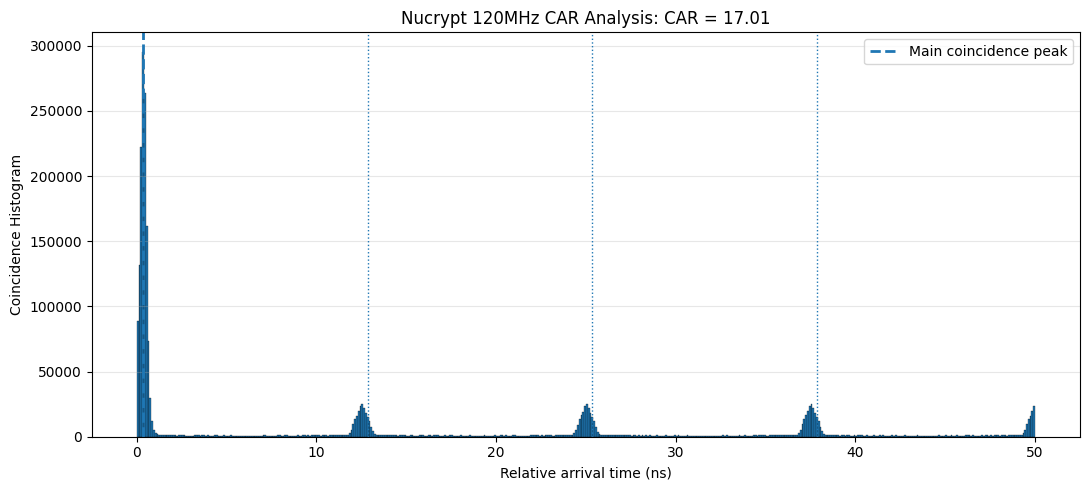

In [7]:
plt.figure(figsize=(11, 5))

plt.bar(
    df["BinCenter_ns"],
    df[hist_col],
    width=0.1,
    edgecolor="black",
    linewidth=0.2
)

# Mark main peak
plt.axvline(
    main_peak_time_ns,
    linestyle="--",
    linewidth=2,
    label="Main coincidence peak"
)

# Mark accidental side peaks
for t in side_peak_times:
    plt.axvline(
        t,
        linestyle=":",
        linewidth=1
    )

plt.xlabel("Relative arrival time (ns)")
plt.ylabel("Coincidence Histogram")
plt.title(f"Nucrypt 120MHz CAR Analysis: CAR = {CAR:.2f}")
plt.grid(axis="y", alpha=0.3)
#plt.xlim([10,15])
#plt.ylim([0,50000])
plt.legend()
plt.tight_layout()
plt.show()